In [1]:
user_id = "tp99965073"
domain = "AXISB.COM"
app_name = "Fraud_&_AML"
yarn_queue = "root.DEV.AML_FRAUD_CS"

EXECUTOR_MEMORY=28
EXECUTOR_CORE=4

INITIAL_EXECUTORS=8
MAX_EXECUTORS=50     # 16x4 = 64 cores; lower this to your approved cap if smaller (YARN grants only what is free)
MIN_EXECUTORS=2

In [2]:
import sys
from pyspark.sql import SparkSession, SQLContext
from pyspark import SparkContext, SparkConf
from pyspark.sql import functions as F
from pyspark.sql import Window as W
import pyspark.sql.types as T
from datetime import datetime, date,timedelta
from dateutil.relativedelta import relativedelta
import pandas as pd
import time
import numpy as np


from IPython.core.display import HTML
display(HTML("<style>pre { white-space: pre !important; }</style>"))


# Construct the keytab path and the principal
keytab_path = f"/home/{user_id}@axisb.com/{user_id}.keytab"
principal = f"{user_id}@{domain}"

# Execute the commands
!kdestroy
!kinit -k -t "{keytab_path}" {principal}
try:
    spark.stop()
    print("Existing Spark Session Killed")
except:
    print("")
print("Creating new spark session since: ", datetime.now())
spark = SparkSession\
    .builder\
    .appName(f'JH_{user_id}_{app_name}')\
    .config('spark.sql.execution.arrow.enabled', "true")\
    .config('spark.master','yarn')\
    .config('spark.deploy-mode', 'cluster')\
    .config("spark.principal",f"{user_id}@AXISB.COM") \
    .config("spark.keytab",f"{user_id}.keytab")\
    .config('spark.dynamicAllocation.enabled','true') \
    .config('spark.dynamicAllocation.minExecutors',MIN_EXECUTORS) \
    .config('spark.dynamicAllocation.initialExecutors',INITIAL_EXECUTORS) \
    .config('spark.dynamicAllocation.maxExecutors',MAX_EXECUTORS) \
    .config('spark.executor.cores',EXECUTOR_CORE) \
    .config('spark.dynamicAllocation.executorAllocationRatio','0.8')\
    .config('spark.executor.memory',f'{EXECUTOR_MEMORY}g')\
    .config('spark.driver.memory','16g')\
    .config('spark.driver.cores','1')\
    .config('spark.executor.memoryOverhead','8g')\
    .config('spark.sql.shuffle.partitions','12000')\
    .config('spark.shuffle.service.enabled','true')\
    .config('spark.network.timeout','600s')\
    .config('spark.shuffle.io.maxRetries','10')\
    .config('spark.shuffle.io.retryWait','15s')\
    .config('spark.stage.maxConsecutiveAttempts','8')\
    .config('spark.maxRemoteBlockSizeFetchToMem','512m')\
    .config("spark.sql.broadcastTimeout", "-1")\
    .config("spark.sql.parquet.int96RebaseModeInRead", "LEGACY")\
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY")\
    .config("spark.sql.parquet.int96RebaseModeInRead", "CORRECTED")\
    .config("spark.sql.parquet.int96RebaseModeInWrite", "CORRECTED")\
    .config("spark.sql.parquet.datetimeRebaseModeInRead", "CORRECTED")\
    .config("spark.sql.parquet.datetimeRebaseModeInWrite", "CORRECTED")\
    .config("spark.yarn.queue", yarn_queue)\
    .config('spark.sql.sources.partitionOverwriteMode', 'dynamic')\
    .config('spark.hadoop.hive.exec.dynamic.partition.mode', 'nonstrict')\
    .config('spark.sql.parquet.output.committer.class', 'org.apache.parquet.hadoop.ParquetOutputCommitter')\
    .config('spark.sql.sources.commitProtocolClass', 'org.apache.spark.sql.execution.datasources.SQLHadoopMapReduceCommitProtocol')\
    .config("spark.jars", "hdfs:///jars/iceberg-spark-runtime-3.3_2.12-1.6.1.jar,/opt/cloudera/parcels/CDH/jars/ojdbc8.jar")\
    .config('spark.sql.extensions', 'org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions')\
    .config('spark.sql.catalog.spark_catalog', 'org.apache.iceberg.spark.SparkSessionCatalog')\
    .config('spark.sql.catalog.spark_catalog.type', 'hive')\
    .config('spark.sql.adaptive.enabled', 'true')\
    .config('spark.sql.adaptive.coalescePartitions.enabled', 'true')\
    .config('spark.sql.adaptive.skewJoin.enabled', 'true')\
    .config('spark.sql.adaptive.autoBroadcastJoinThreshold','50MB')\
    .config("spark.sql.legacy.allowNonEmptyLocationInCTAS", "true")\
    .enableHiveSupport()\
    .getOrCreate()
sc = SparkContext.getOrCreate()
print("New Spark Session created at : ", datetime.now())

new_log_level = "ERROR"
sc.setLogLevel(new_log_level)
print(f"Logs level set to {new_log_level}")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)


Creating new spark session since:  2026-07-08 08:31:07.946862


26/07/08 08:31:09 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
26/07/08 08:31:09 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/08 08:31:09 WARN  spark.SparkConf: [main]: The configuration key 'spark.maxRemoteBlockSizeFetchToMem' has been deprecated as of Spark 3.0 and may be removed in the future. Please use the new key 'spark.network.maxRemoteBlockSizeFetchToMem' instead.
26/07/08 08:31:09 WARN  spark.SparkConf: [Thread-9]: The configuration key 'spark.maxRemoteBlockSizeFetch

New Spark Session created at :  2026-07-08 08:31:21.435520
Logs level set to ERROR


# Notebook 08 (v2) — INVESTIGATION output + GRAPH VISUALISATION (the analyst-facing deliverable)

Everything so far produced *scores*. This notebook turns them into something a fraud analyst can act on:
1. **A ranked review queue** (top-K customers per anchor) with a plain-English **`why_flagged`** reason per
   customer — which signals fired (shared rare mule, close to known fraud, shared cash-out ATM, dense Fraudar
   block, ...).
2. **Ego-network graph pictures** of the top graph-connected customers: the candidate's account(s) ->
   the RARE mule(s) they pay -> the KNOWN-fraud (seed) accounts that pay the same mule. This draws the actual
   collector ring the features were built from — the first time the graph is visualised in the whole project.

It reuses the deployable ranker (`_v2_final_scores` from 06) + the leak-free features (`_v2_final_features`)
+ the edge tables. **No new heavy compute** — the review queue is tiny and each ring subgraph is a handful of
nodes collected to the driver and drawn with plain matplotlib (no networkx dependency). `target_fraud` is
shown ONLY as an outcome label to demonstrate precision — it is never used to rank. Run AFTER 06 (07 optional).
Run session cells first, then top to bottom.


In [3]:
# ---- PARAMETERS ----
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark import StorageLevel
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython.display as _disp

WRITE_DB = "payment_cards_dev"; EMP = "TP99965073"
SCORE_TBL = f"{WRITE_DB}.{EMP}_v2_final_scores"          # nb 06 deployable ranker (cust, anchor, target, final_score, risk_pctl)
FEATS_TBL = f"{WRITE_DB}.{EMP}_v2_final_features"        # nb 06 all leak-free features (for the reasons)
EDGES_TXN = f"{WRITE_DB}.{EMP}_v2_edges_transferred"     # nb 02b: src, dst, txn_month, sum_amount
OWN_TBL   = f"{WRITE_DB}.{EMP}_v2_edges_ownership"       # nb 02 : src=cust, dst=acct
SUBG_NIDX = f"{WRITE_DB}.{EMP}_v2_subgraph_node_index"   # nb 03 : id, is_known_bad, is_candidate, target_fraud, anchor_month

ANCHOR_TRAILING = {
    "202509": ["202506", "202507", "202508"],
    "202510": ["202507", "202508", "202509"],
    "202511": ["202508", "202509", "202510"],
}
INVESTIGATE_ANCHOR = "202509"     # which cohort to build the queue + rings for (Sep = most matured)
TOP_N = 50                        # rows in the saved review queue
N_VIZ = 6                         # how many top graph-connected customers to DRAW
RARE_BENEF_MAX = 20               # rare-beneficiary cap (identical to nb 04/05 — the ring is on rare mules)
MAX_MULES_VIZ = 6                 # cap mules per drawn ring (readability)
MAX_SEEDS_PER_MULE = 3            # cap seed feeders per mule (readability)
MAX_FEEDERS_PER_MULE = 8          # cap OTHER co-feeders per mule (used by both the columnar ring and networkx view)
MAX_COFEEDERS_VIZ = 10            # cap total co-feeder nodes drawn in the columnar ring (readability)
REASON_FEATS = ["n_shared_mule", "closeness_to_bad", "n_shared_atm", "comm_bad_rate", "fraudar_score", "in_dense_block"]

OUT_QUEUE = f"{WRITE_DB}.{EMP}_v2_investigation_queue"

spark.conf.set("spark.sql.shuffle.partitions", "256")

def save_overwrite(df, t):
    spark.sql("DROP TABLE IF EXISTS " + t); df.write.mode("overwrite").saveAsTable(t)

print("investigation | anchor:", INVESTIGATE_ANCHOR, "| top-N queue:", TOP_N, "| rings to draw:", N_VIZ)


investigation | anchor: 202509 | top-N queue: 50 | rings to draw: 6


## A. Build the ranked review queue with plain-English reasons
Rank customers by `risk_pctl` (06's early-warning ordering) within the anchor, attach every feature value,
and translate the non-zero signals into a `why_flagged` sentence an analyst can read.


In [4]:
feats_cols = spark.table(FEATS_TBL).columns
have = [c for c in REASON_FEATS if c in feats_cols]
scores = spark.table(SCORE_TBL).select("cust", "anchor_month", "target_fraud", "final_score", "risk_pctl")
feats  = spark.table(FEATS_TBL).select("cust", "anchor_month", *have)
qa = (scores.where(F.col("anchor_month") == INVESTIGATE_ANCHOR)
      .join(feats, ["cust", "anchor_month"], "left"))
w = Window.partitionBy("anchor_month").orderBy(F.col("risk_pctl").desc_nulls_last())
top = qa.withColumn("rank", F.row_number().over(w)).where(F.col("rank") <= TOP_N)
tp = top.toPandas()

def reasons(r):
    out = []
    if float(r.get("n_shared_mule", 0) or 0) > 0:
        out.append("shares %d rare mule(s) with known fraud" % int(r["n_shared_mule"]))
    if float(r.get("n_shared_atm", 0) or 0) > 0:
        out.append("shares %d cash-out ATM(s) with known fraud" % int(r["n_shared_atm"]))
    cl = float(r.get("closeness_to_bad", 0) or 0)
    if cl > 0:
        out.append("close to known fraud in the transfer graph (closeness %.2f)" % cl)
    if float(r.get("in_dense_block", 0) or 0) > 0:
        out.append("member of a dense Fraudar block (high-precision flag)")
    if float(r.get("comm_bad_rate", 0) or 0) > 0:
        out.append("in a community with elevated fraud density (%.3f)" % float(r["comm_bad_rate"]))
    if float(r.get("fraudar_score", 0) or 0) > 0:
        out.append("elevated Fraudar suspiciousness score")
    return " | ".join(out) if out else "no graph signal (ranked low)"

tp["why_flagged"] = tp.apply(reasons, axis=1)
QUEUE_COLS = ["anchor_month", "rank", "cust", "risk_pctl", "final_score", "target_fraud", "why_flagged"] + have
qout = spark.createDataFrame(tp[QUEUE_COLS])
save_overwrite(qout, OUT_QUEUE)
print("saved review queue:", OUT_QUEUE, "| rows:", len(tp))
_disp.display(tp[["rank", "cust", "risk_pctl", "target_fraud", "why_flagged"]].head(20))


Hive Session ID = b9232dc0-9c83-455f-9c8f-eeee714ac234
/opt/cloudera/parcels/SPARK3-3.3.2.3.3.7190.10-1-1.p0.59394740/lib/spark3/python/pyspark/sql/pandas/conversion.py:604: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  [(c, t) for (_, c), t in zip(pdf_slice.iteritems(), arrow_types)]
                                                                                

saved review queue: payment_cards_dev.TP99965073_v2_investigation_queue | rows: 50


,rank,cust,risk_pctl,target_fraud,why_flagged
0,1,875801020,100.000000,0,shares 8 rare mule(s) with known fraud | share...
1,2,076023321,99.998402,0,shares 1 rare mule(s) with known fraud | share...
2,3,857341914,99.996805,0,shares 3 rare mule(s) with known fraud | share...
3,4,960352693,99.995207,0,shares 1 rare mule(s) with known fraud | share...
4,5,120048249,99.993610,0,shares 1 rare mule(s) with known fraud | share...
5,6,865791434,99.992012,0,shares 2 rare mule(s) with known fraud | share...
6,7,847057480,99.990415,0,shares 2 rare mule(s) with known fraud | share...
7,8,890953772,99.988817,0,shares 2 rare mule(s) with known fraud | share...
8,9,120059940,99.987220,0,shares 1 rare mule(s) with known fraud | share...
9,10,891389803,99.985622,0,shares 1 rare mule(s) with known fraud | share...


## B. Queue quality — which signals fire, and how precise is the top of the queue
For the top-N: how many actually turned out fraud (precision), and how often each signal fired. This is the
operational read: "if an analyst reviews these N, how many frauds do they hit, and on what evidence."


In [5]:
n_top = len(tp); n_fraud = int(tp["target_fraud"].sum())
print("=== top-%d review queue @ %s ===" % (n_top, INVESTIGATE_ANCHOR))
print("   precision of the top-%d = %d fraud / %d reviewed = %.1f%%"
      % (n_top, n_fraud, n_top, 100.0 * n_fraud / max(n_top, 1)))
for c in have:
    fired = int((tp[c].astype(float) > 0).sum())
    fired_bad = int(((tp[c].astype(float) > 0) & (tp["target_fraud"] == 1)).sum())
    print("   signal %-18s fired on %3d/%d queued  (of which %d are fraud)" % (c, fired, n_top, fired_bad))


=== top-50 review queue @ 202509 ===
   precision of the top-50 = 3 fraud / 50 reviewed = 6.0%
   signal n_shared_mule      fired on  47/50 queued  (of which 3 are fraud)
   signal closeness_to_bad   fired on  36/50 queued  (of which 3 are fraud)
   signal n_shared_atm       fired on  31/50 queued  (of which 3 are fraud)
   signal comm_bad_rate      fired on   4/50 queued  (of which 3 are fraud)
   signal fraudar_score      fired on  47/50 queued  (of which 3 are fraud)
   signal in_dense_block     fired on   2/50 queued  (of which 1 are fraud)


## C. Reconstruct the RARE collector-ring substrate for this anchor (same recipe as nb 04/05)
Rare transfer edges (beneficiary window fan-in <= `RARE_BENEF_MAX`), the seed (known-bad) accounts, and the
seed-mules (rare beneficiaries a seed pays). We then pull, for the top graph-connected customers only, the
edges of their ring and collect them to the driver to draw.


In [6]:
months = ANCHOR_TRAILING[INVESTIGATE_ANCHOR]
e0 = (spark.table(EDGES_TXN).where(F.col("txn_month").isin(*months))
      .select("src", "dst", F.col("sum_amount").cast("double").alias("amt"))
      .where(F.col("src") != F.col("dst")))
fanin = e0.groupBy("dst").agg(F.countDistinct("src").alias("fi"))
rare = fanin.where(F.col("fi") <= RARE_BENEF_MAX).select("dst")
e = (e0.join(rare, "dst", "inner").groupBy("src", "dst").agg(F.sum("amt").alias("amt"))
     .persist(StorageLevel.DISK_ONLY))
e.count()
lab = spark.table(SUBG_NIDX).where(F.col("anchor_month") == INVESTIGATE_ANCHOR)
seeds = lab.where(F.col("is_known_bad") == 1).select(F.col("id").alias("seed_acc")).distinct()
seed_mules = (e.alias("e").join(seeds.alias("s"), F.col("e.src") == F.col("s.seed_acc"))
              .select(F.col("e.dst").alias("mule")).distinct())

# customers to DRAW = the DENSEST rings among the queued graph-connected customers (most shared mules, then
# highest risk). Showcases real ring structure instead of thin 1-mule chains; the queue itself stays risk-ranked.
_gc = tp[tp.get("n_shared_mule", pd.Series([0] * len(tp))).astype(float) > 0].copy()
viz = _gc.sort_values(["n_shared_mule", "risk_pctl"], ascending=[False, False]).head(N_VIZ).reset_index(drop=True)
viz_custs = viz["cust"].tolist()
print("drawing the %d densest rings among queued graph-connected customers:" % len(viz_custs),
      [(str(c)[-6:], int(m)) for c, m in zip(viz_custs, viz["n_shared_mule"])])

cdf = pd.DataFrame(columns=["cust", "cand_acct", "mule", "amt"])
sdf = pd.DataFrame(columns=["seed_acct", "mule"])
fdf = pd.DataFrame(columns=["feeder", "mule"])
if viz_custs:
    own = spark.table(OWN_TBL).select(F.col("src").alias("cust"), F.col("dst").alias("acct"))
    viz_accts = own.where(F.col("cust").isin(viz_custs))
    cand_e = (e.alias("e").join(viz_accts.alias("v"), F.col("e.src") == F.col("v.acct"))
              .join(seed_mules.alias("m"), F.col("e.dst") == F.col("m.mule"))
              .select(F.col("v.cust").alias("cust"), F.col("e.src").alias("cand_acct"),
                      F.col("e.dst").alias("mule"), F.col("e.amt").alias("amt")).distinct())
    cand_rows = cand_e.collect()
    cdf = pd.DataFrame([(r["cust"], r["cand_acct"], r["mule"], float(r["amt"])) for r in cand_rows],
                       columns=["cust", "cand_acct", "mule", "amt"])
    if len(cdf):
        mules = cand_e.select("mule").distinct()
        seed_e = (e.alias("e").join(seeds.alias("s"), F.col("e.src") == F.col("s.seed_acc"))
                  .join(mules.alias("m"), F.col("e.dst") == F.col("m.mule"))
                  .select(F.col("e.src").alias("seed_acct"), F.col("e.dst").alias("mule")).distinct())
        sdf = pd.DataFrame([(r["seed_acct"], r["mule"]) for r in seed_e.collect()], columns=["seed_acct", "mule"])
        # ALL feeders of the shared mules (capped per mule) -> the ring's other accounts, for the neighbourhood view
        wf = Window.partitionBy("mule").orderBy(F.col("feeder"))
        feeders = (e.alias("e").join(mules.alias("m"), F.col("e.dst") == F.col("m.mule"))
                   .select(F.col("e.src").alias("feeder"), F.col("e.dst").alias("mule")))
        feeders_c = feeders.withColumn("rn", F.row_number().over(wf)).where(F.col("rn") <= MAX_FEEDERS_PER_MULE).drop("rn")
        fdf = pd.DataFrame([(r["feeder"], r["mule"]) for r in feeders_c.collect()], columns=["feeder", "mule"])
print("collected ring edges: candidate->mule =", len(cdf), "| seed->mule =", len(sdf), "| all feeders =", len(fdf))


drawing the 6 densest rings among queued graph-connected customers: [('801020', 8), ('783478', 6), ('797875', 5), ('349754', 5), ('487069', 5), ('341914', 3)]


[Stage 88:=====================================================>(254 + 2) / 256]

collected ring edges: candidate->mule = 32 | seed->mule = 34 | all feeders = 216


## D. Draw the FULL collector ring — candidate + co-feeders -> shared RARE mule <- known-fraud (seed)
Columnar layout (no networkx needed). LEFT column = the accounts feeding the shared mules: the candidate (red)
stacked above the OTHER co-feeders of the same mules (grey) — this is the ring's real size. MIDDLE = the shared
RARE mules (orange). RIGHT = the KNOWN-fraud seeds (black). Red line = candidate pays the mule, width ~ transfer
amount; thin grey = a co-feeder pays it; dashed = a known fraud pays the SAME mule. The full ring, not a chain.


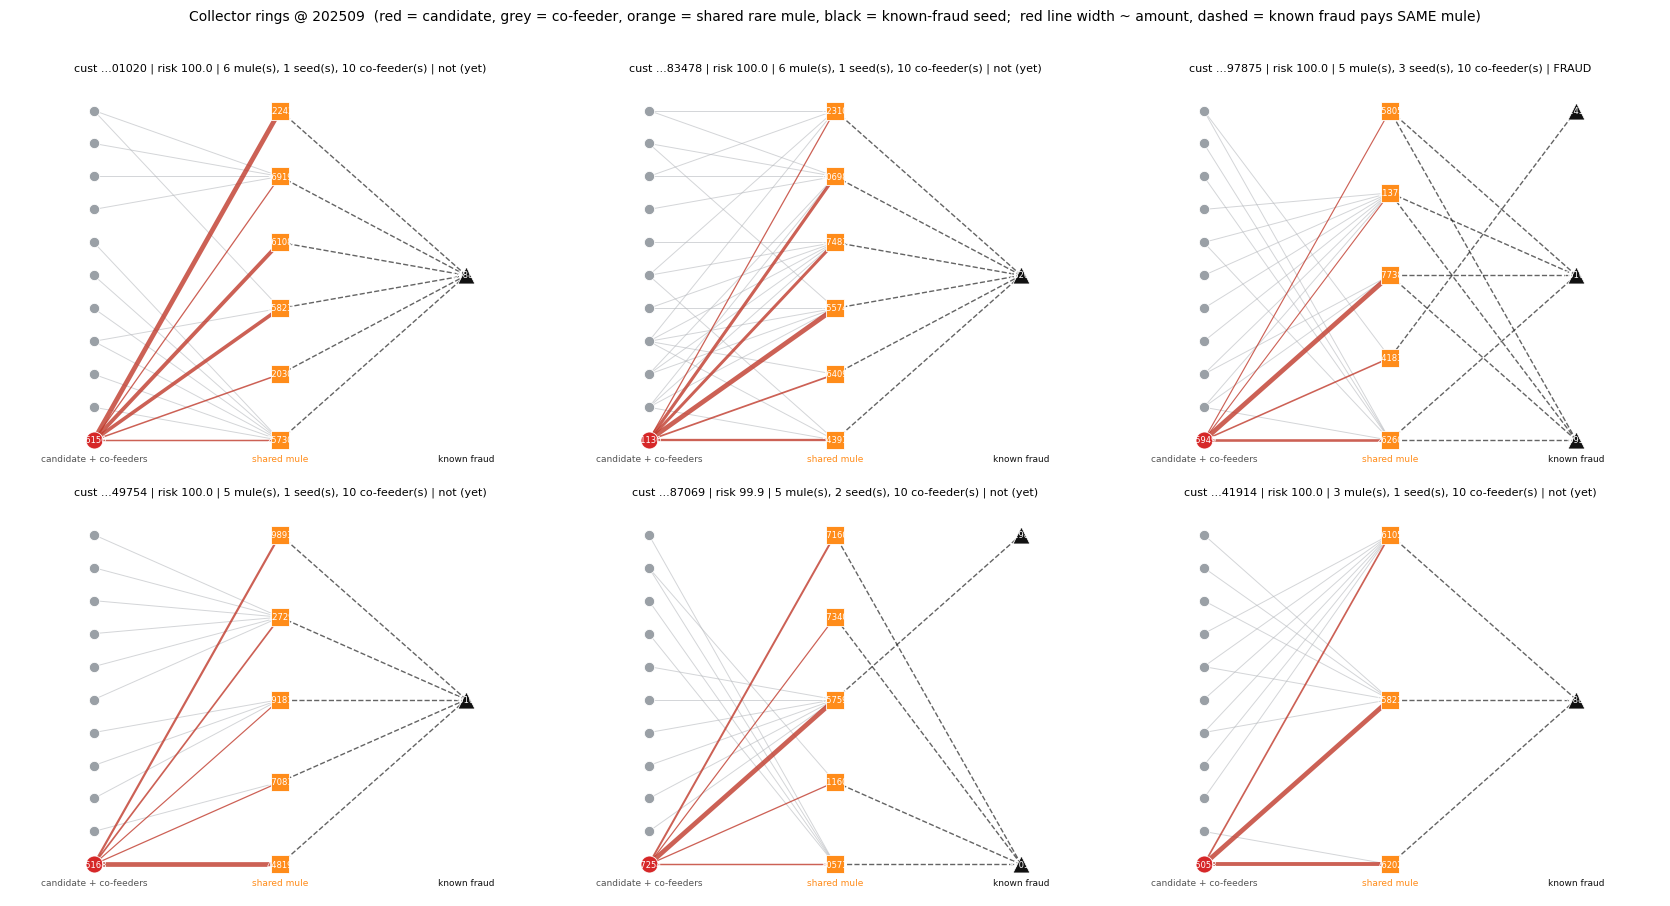

DataFrame[src: string, dst: string, amt: double]

In [7]:
def _short(x):
    return str(x)[-5:]

def _ypos(n):
    return np.linspace(0.03, 0.97, n) if n > 1 else np.array([0.5])

drew = False
if len(viz) > 0 and len(cdf) > 0:
    ncol = 3; nrow = int(np.ceil(len(viz) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.6 * ncol, 4.6 * nrow))
    axes = np.array(axes).reshape(-1)
    for i in range(len(viz)):
        ax = axes[i]; vr = viz.iloc[i]; C = vr["cust"]
        cm = cdf[cdf.cust == C]
        mset = list(dict.fromkeys(cm["mule"].tolist()))[:MAX_MULES_VIZ]
        cm = cm[cm.mule.isin(mset)]
        cand_accts = list(dict.fromkeys(cm["cand_acct"].tolist()))
        sm2 = []
        for m in mset:
            for s in sdf[sdf.mule == m]["seed_acct"].tolist()[:MAX_SEEDS_PER_MULE]:
                sm2.append((s, m))
        seed_accts = list(dict.fromkeys([s for s, _ in sm2]))
        # OTHER co-feeders of the same mules (not the candidate, not a seed) -> shows the ring's real size
        exclude = set(cand_accts) | set(seed_accts)
        co_e = fdf[fdf.mule.isin(mset) & (~fdf.feeder.isin(exclude))]
        co_nodes = list(dict.fromkeys(co_e["feeder"].tolist()))[:MAX_COFEEDERS_VIZ]
        co_e = co_e[co_e.feeder.isin(co_nodes)]
        left = [("c", a) for a in cand_accts] + [("o", a) for a in co_nodes]   # candidate above co-feeders
        yl = _ypos(len(left)); ym = _ypos(len(mset)); ys = _ypos(len(seed_accts))
        pos = {}
        for k, (t, a) in enumerate(left):  pos[(t, a)] = (0.0, yl[k])
        for k, m in enumerate(mset):       pos[("m", m)] = (1.0, ym[k])
        for k, s in enumerate(seed_accts): pos[("s", s)] = (2.0, ys[k])
        amax = float(cm["amt"].max()) if len(cm) and cm["amt"].max() > 0 else 1.0
        for _, er in cm.iterrows():                                            # candidate -> mule (width ~ amount)
            x1, y1 = pos[("c", er["cand_acct"])]; x2, y2 = pos[("m", er["mule"])]
            ax.plot([x1, x2], [y1, y2], color="#c0392b", lw=0.8 + 2.6 * (float(er["amt"]) / amax), alpha=0.8, zorder=2)
        for _, er in co_e.iterrows():                                          # co-feeder -> mule
            if ("o", er["feeder"]) not in pos or ("m", er["mule"]) not in pos: continue
            x1, y1 = pos[("o", er["feeder"])]; x2, y2 = pos[("m", er["mule"])]
            ax.plot([x1, x2], [y1, y2], color="#b0b3b8", lw=0.7, alpha=0.55, zorder=1)
        for s, m in sm2:                                                       # known fraud -> mule (dashed)
            x1, y1 = pos[("s", s)]; x2, y2 = pos[("m", m)]
            ax.plot([x1, x2], [y1, y2], color="#222222", lw=1.0, alpha=0.7, ls="--", zorder=2)
        style = {"c": ("#d62728", "o", 150), "o": ("#9aa0a6", "o", 55), "m": ("#ff8c1a", "s", 150), "s": ("#111111", "^", 150)}
        for (typ, a), (x, y) in pos.items():
            col, mk, sz = style[typ]
            ax.scatter([x], [y], c=col, marker=mk, s=sz, zorder=3, edgecolors="white", linewidths=0.6)
            if typ in ("c", "m", "s"):
                ax.annotate(_short(a), (x, y), fontsize=6, ha="center", va="center", color="white", zorder=4)
        outcome = "FRAUD" if int(vr["target_fraud"]) == 1 else "not (yet)"
        ax.set_title("cust ...%s | risk %.1f | %d mule(s), %d seed(s), %d co-feeder(s) | %s"
                     % (_short(C), float(vr["risk_pctl"]), len(mset), len(seed_accts), len(co_nodes), outcome), fontsize=8)
        ax.set_xlim(-0.45, 2.45); ax.set_ylim(-0.06, 1.06); ax.axis("off")
        ax.text(0.0, -0.03, "candidate + co-feeders", ha="center", fontsize=6.5, color="#555555")
        ax.text(1.0, -0.03, "shared mule", ha="center", fontsize=6.5, color="#ff8c1a")
        ax.text(2.0, -0.03, "known fraud", ha="center", fontsize=6.5, color="#111111")
    for j in range(len(viz), len(axes)):
        axes[j].axis("off")
    fig.suptitle("Collector rings @ %s  (red = candidate, grey = co-feeder, orange = shared rare mule, black = known-fraud "
                 "seed;  red line width ~ amount, dashed = known fraud pays SAME mule)" % INVESTIGATE_ANCHOR, fontsize=10)
    fig.tight_layout(rect=[0, 0, 1, 0.97]); plt.show(); drew = True
if not drew:
    print("No graph-connected customers in the top-%d to draw (all top rows have n_shared_mule=0), or no ring edges "
          "collected. The rings only exist for the graph-connected slice; the rest are ranked by other signals." % TOP_N)

e.unpersist()


## E. networkx ego-network — richer neighbourhood CONTEXT (falls back to D's columnar ring if networkx absent)
The columnar ring in D is the crisp "why flagged". This is the context: a spring-layout of each top customer's
neighbourhood showing the shared mules, the known-fraud feeders, AND the OTHER accounts feeding the same mules
(the ring's real size). Node size ~ degree; colour = role. Wrapped in an import guard so a cluster without
networkx degrades gracefully (the D rings still stand) instead of crashing mid-notebook.


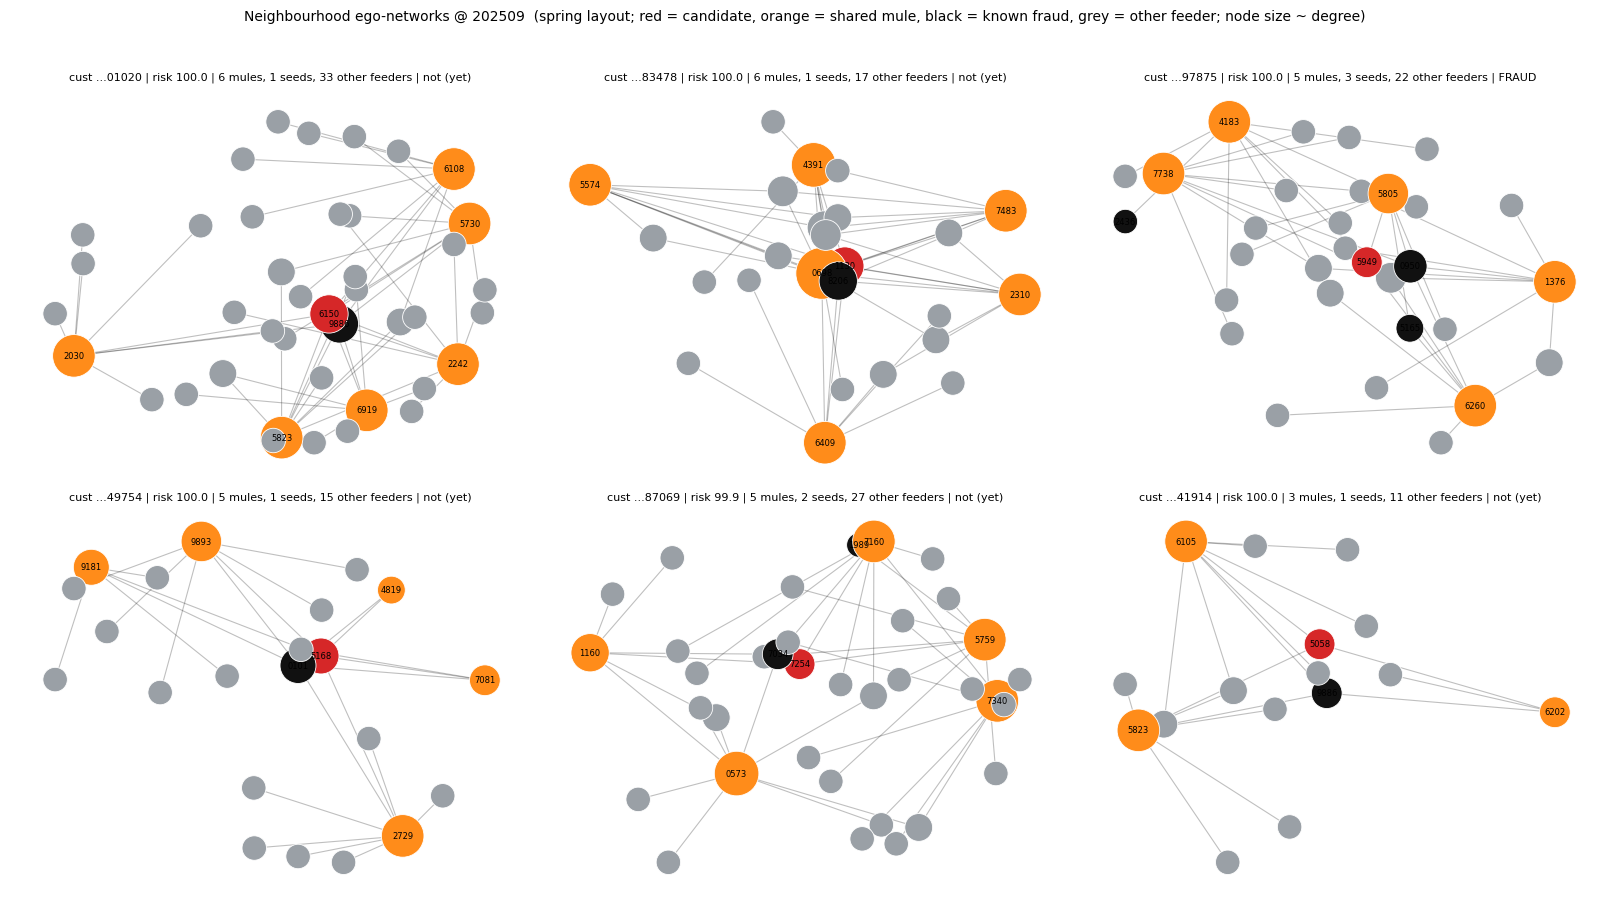

In [8]:
try:
    import networkx as nx
    _HAS_NX = True
except Exception as _e:
    _HAS_NX = False
    print("networkx unavailable (%s) -> skipping the neighbourhood view; the columnar rings in D still cover it." % _e)

if _HAS_NX and len(viz) > 0 and len(cdf) > 0 and len(fdf) > 0:
    seed_set = set(sdf["seed_acct"].astype(str).tolist())
    ncol = 3; nrow = int(np.ceil(len(viz) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.4 * ncol, 4.6 * nrow)); axes = np.array(axes).reshape(-1)
    for i in range(len(viz)):
        ax = axes[i]; vr = viz.iloc[i]; C = vr["cust"]
        my_mules = list(dict.fromkeys(cdf[cdf.cust == C]["mule"].astype(str).tolist()))[:MAX_MULES_VIZ]
        my_cands = set(cdf[(cdf.cust == C) & (cdf.mule.astype(str).isin(my_mules))]["cand_acct"].astype(str).tolist())
        fe = fdf[fdf.mule.astype(str).isin(my_mules)]
        G = nx.DiGraph()
        for _, er in fe.iterrows():
            G.add_edge(str(er["feeder"]), str(er["mule"]))
        if G.number_of_nodes() == 0:
            ax.axis("off"); continue
        def _role(node, mm=my_mules, mc=my_cands, ss=seed_set):
            if node in mm: return "mule"
            if node in mc: return "cand"
            if node in ss: return "seed"
            return "cofeeder"
        cmap = {"cand": "#d62728", "mule": "#ff8c1a", "seed": "#111111", "cofeeder": "#9aa0a6"}
        roles = {n: _role(n) for n in G.nodes()}
        colors = [cmap[roles[n]] for n in G.nodes()]
        sizes = [220 + 90 * G.degree(n) for n in G.nodes()]
        pos = nx.spring_layout(G, k=0.9, seed=42, iterations=60)
        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, arrows=False, width=0.8)
        nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=sizes, edgecolors="white", linewidths=0.6)
        lab = {n: str(n)[-4:] for n in G.nodes() if roles[n] in ("mule", "cand", "seed")}
        nx.draw_networkx_labels(G, pos, labels=lab, ax=ax, font_size=6)
        n_seed = sum(1 for v in roles.values() if v == "seed"); n_co = sum(1 for v in roles.values() if v == "cofeeder")
        ax.set_title("cust ...%s | risk %.1f | %d mules, %d seeds, %d other feeders | %s"
                     % (str(C)[-5:], float(vr["risk_pctl"]), len(my_mules), n_seed, n_co,
                        "FRAUD" if int(vr["target_fraud"]) == 1 else "not (yet)"), fontsize=8)
        ax.axis("off")
    for j in range(len(viz), len(axes)):
        axes[j].axis("off")
    fig.suptitle("Neighbourhood ego-networks @ %s  (spring layout; red = candidate, orange = shared mule, "
                 "black = known fraud, grey = other feeder; node size ~ degree)" % INVESTIGATE_ANCHOR, fontsize=10)
    fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
elif _HAS_NX:
    print("No graph-connected customers / feeder edges to render in the neighbourhood view (columnar rings in D still apply).")


## H. Done — summary

In [9]:
import pandas as _pd
_fe = spark.table(FEATS_TBL).where(F.col("anchor_month") == INVESTIGATE_ANCHOR).toPandas()
for _col in _fe.columns:
    if _col not in ("cust", "anchor_month"):
        _fe[_col] = _pd.to_numeric(_fe[_col], errors="coerce")
_base_rate = 100.0 * _fe["target_fraud"].fillna(0).astype(int).mean() if "target_fraud" in _fe.columns else 0.0

def _tail(x, n=6):
    return "..." + str(x)[-n:]

def _pick(col, prefer_fraud=True):
    # the most illustrative REAL customer for `col`: highest value, preferring a confirmed fraud
    if col not in _fe.columns:
        return None
    d = _fe[_fe[col].fillna(0) > 0]
    if not len(d):
        return None
    if prefer_fraud and "target_fraud" in d.columns and (d["target_fraud"] == 1).any():
        d = d[d["target_fraud"] == 1]
    return d.sort_values(col, ascending=False).iloc[0]

def _outcome(r):
    return "later CONFIRMED fraud" if int(r.get("target_fraud", 0) or 0) == 1 else "clean / not yet fraud"

print("=== WORKED EXAMPLES (anchor %s | base fraud rate %.2f%%) ===\n" % (INVESTIGATE_ANCHOR, _base_rate))

# 1) n_shared_mule — enrich with the REAL shared-mule + known-fraud account IDs from the ring edges (section C)
_r = _pick("n_shared_mule")
if _r is not None:
    _cst = _r["cust"]; _nm = int(_r["n_shared_mule"])
    _line = "1) SHARED MULE (n_shared_mule=%d) - customer %s pays %d private mule(s) that a known fraud also pays; %s." % (
        _nm, _tail(_cst), _nm, _outcome(_r))
    _cm = cdf[cdf.cust == _cst] if len(cdf) else cdf
    if len(_cm):
        _m = _cm.iloc[0]["mule"]; _amt = float(_cm.iloc[0]["amt"])
        _sd = sdf[sdf.mule == _m] if len(sdf) else sdf
        _sname = _tail(_sd.iloc[0]["seed_acct"]) if len(_sd) else "a known-fraud account"
        _line += "\n     e.g. acct %s -> mule %s (Rs %.0f); known fraud %s -> the SAME mule %s." % (
            _tail(_cm.iloc[0]["cand_acct"]), _tail(_m), _amt, _sname, _tail(_m))
    print(_line + "\n")

# 2) closeness_to_bad
_r = _pick("closeness_to_bad")
if _r is not None:
    _hops = _r["min_hops_to_bad"] if "min_hops_to_bad" in _fe.columns and _pd.notna(_r.get("min_hops_to_bad")) else None
    _h = (" in %d hop(s)" % int(_hops)) if _hops is not None else ""
    print("2) CLOSE TO FRAUD (closeness_to_bad=%.2f) - customer %s reaches a known fraud%s along time-ordered money flow; %s.\n"
          % (float(_r["closeness_to_bad"]), _tail(_r["cust"]), _h, _outcome(_r)))

# 3) out_deg
_r = _pick("out_deg")
if _r is not None:
    print("3) FAN-OUT (out_deg=%d) - customer %s sends money to %d distinct private accounts (dispersal / structuring-out); %s.\n"
          % (int(_r["out_deg"]), _tail(_r["cust"]), int(_r["out_deg"]), _outcome(_r)))

# 4) passthrough_ratio
_r = _pick("passthrough_ratio")
if _r is not None:
    print("4) PASS-THROUGH (passthrough_ratio=%.2f) - customer %s's money-in ~ money-out (near 1 = flows straight through, a layering mule); %s.\n"
          % (float(_r["passthrough_ratio"]), _tail(_r["cust"]), _outcome(_r)))

# 5) on_3cycle
_r = _pick("on_3cycle")
if _r is not None:
    _nc = int(_r.get("n_3cycle_as_a", 0) or 0)
    print("5) ROUND-TRIP CYCLE (on_3cycle=1%s) - customer %s sits on a 3-account money loop (A->B->C->A); %s.\n"
          % ((", originates %d" % _nc) if _nc else "", _tail(_r["cust"]), _outcome(_r)))

# 6) Fraudar dense block
_r = _pick("in_dense_block")
if _r is None:
    _r = _pick("fraudar_score")
if _r is not None:
    _bd = float(_r.get("block_density", 0) or 0)
    print("6) DENSE FRAUD BLOCK (in_dense_block=%d, density=%.3f) - customer %s belongs to a tightly-coordinated ring found by Fraudar; %s.\n"
          % (int(_r.get("in_dense_block", 0) or 0), _bd, _tail(_r["cust"]), _outcome(_r)))

# 7) shared cash-out ATM
_r = _pick("n_shared_atm")
if _r is not None:
    print("7) SHARED CASH-OUT (n_shared_atm=%d) - customer %s cashes out at %d ATM/POS terminal(s) a known fraud also uses; %s.\n"
          % (int(_r["n_shared_atm"]), _tail(_r["cust"]), int(_r["n_shared_atm"]), _outcome(_r)))

print("Each card is a REAL customer in this cohort - pair it with the ring picture (D) and the excalidraw motif shape to explain the feature.")

[Stage 89:======================================================> (31 + 1) / 32]

=== WORKED EXAMPLES (anchor 202509 | base fraud rate 0.15%) ===

1) SHARED MULE (n_shared_mule=9) - customer ...104673 pays 9 private mule(s) that a known fraud also pays; later CONFIRMED fraud.

2) CLOSE TO FRAUD (closeness_to_bad=0.50) - customer ...094281 reaches a known fraud in 1 hop(s) along time-ordered money flow; later CONFIRMED fraud.

3) FAN-OUT (out_deg=81) - customer ...905771 sends money to 81 distinct private accounts (dispersal / structuring-out); later CONFIRMED fraud.

4) PASS-THROUGH (passthrough_ratio=0.47) - customer ...743380's money-in ~ money-out (near 1 = flows straight through, a layering mule); later CONFIRMED fraud.

5) ROUND-TRIP CYCLE (on_3cycle=1, originates 1) - customer ...104673 sits on a 3-account money loop (A->B->C->A); later CONFIRMED fraud.

6) DENSE FRAUD BLOCK (in_dense_block=1, density=0.787) - customer ...104673 belongs to a tightly-coordinated ring found by Fraudar; later CONFIRMED fraud.

7) SHARED CASH-OUT (n_shared_atm=5) - customer ...825

## G. BINNING tied to the examples — how each feature's values map to fraud rate (the mentor's scorecard view)
For each headline feature: its bins (value band → customers → fraud rate → cumulative % of all fraud captured,
riskiest band first), the ONE-LINE "how the algorithm builds it", and the worked-example customer marked in its
bin. This is exactly the binning/sloping the mentor uses — now anchored to a real customer, so you can walk from
"here is the feature" → "here is how we bin it" → "here is a real customer sitting in the top band". Pandas-only
on the already-loaded feature table; no new compute.

In [10]:
BIN_FEATURES = ["n_shared_mule", "closeness_to_bad", "out_deg", "passthrough_ratio", "fraudar_score"]
HOW = {
    "n_shared_mule":    "beneficiary self-join: count of private mules the customer pays that a known fraud also pays",
    "closeness_to_bad": "1/(1+hops) from a time-respecting money-flow BFS started at the known frauds",
    "out_deg":          "out-degree in the transfer graph (distinct private accounts paid)",
    "passthrough_ratio":"least(in,out)/greatest(in,out) of rupee flow through the account (layering)",
    "fraudar_score":    "density spread over the accounts x seed-mules bipartite (Fraudar suspiciousness)",
}

def _bin_series(x, max_bins=8):
    s = _pd.Series(np.asarray(x, float)); nu = int(s.nunique(dropna=True))
    if nu <= 1:
        return np.zeros(len(s), int)
    if nu <= max_bins:
        order = {v: i for i, v in enumerate(sorted(s.dropna().unique()))}
        return s.map(order).fillna(0).astype(int).values
    z = (s == 0); out = np.zeros(len(s), int)
    if z.mean() >= 0.02 and int((~z).sum()) >= max_bins:
        pos = ~z
        qr = _pd.qcut(s[pos].rank(method="first"), q=min(max_bins - 1, int((~z).sum())), labels=False, duplicates="drop")
        out[pos.values] = 1 + qr.astype(int).values; return out
    return _pd.qcut(s.rank(method="first"), q=max_bins, labels=False, duplicates="drop").astype(int).values

_yv = _fe["target_fraud"].fillna(0).astype(int).values if "target_fraud" in _fe.columns else np.zeros(len(_fe), int)
_totbad = int(_yv.sum())
print("=== BINNING tied to the examples (anchor %s | %d frauds) ===\n" % (INVESTIGATE_ANCHOR, _totbad))
for _c in BIN_FEATURES:
    if _c not in _fe.columns:
        continue
    _x = _fe[_c].fillna(0).astype(float).values
    _g = (_pd.DataFrame({"b": _bin_series(_x), "lo": _x, "hi": _x, "y": _yv})
          .groupby("b").agg(cnt=("y", "size"), bad=("y", "sum"), lo=("lo", "min"), hi=("hi", "max"))
          .sort_values("lo", ascending=False))                      # riskiest (highest value) band first
    _g["event_pct"] = (100.0 * _g["bad"] / _g["cnt"]).round(2)
    _g["cum_capt_pct"] = (100.0 * _g["bad"].cumsum() / max(_totbad, 1)).round(1)
    _ex = _pick(_c); _exval = float(_ex[_c]) if _ex is not None else None
    print("-- %-17s (built as: %s) --" % (_c, HOW.get(_c, "")))
    for _, _rr in _g.reset_index().iterrows():
        _rng = ("%.3g" % _rr["lo"]) if _rr["lo"] == _rr["hi"] else ("%.3g..%.3g" % (_rr["lo"], _rr["hi"]))
        _mark = "   <== example customer here" if (_exval is not None and _rr["lo"] - 1e-9 <= _exval <= _rr["hi"] + 1e-9) else ""
        print("   value %-16s | cust %6d | fraud %4d | rate %6.2f%% | cum-capt %5.1f%%%s"
              % (_rng, int(_rr["cnt"]), int(_rr["bad"]), _rr["event_pct"], _rr["cum_capt_pct"], _mark))
    if _exval is not None:
        print("   -> worked example %s has %s=%.3g (marked band above).\n" % (_tail(_ex["cust"]), _c, _exval))
    else:
        print("")
print("READ: riskiest value band first; 'rate' = fraud rate inside that band; 'cum-capt' = share of ALL fraud caught down to here.")
print("Walk it as: the algorithm builds the feature -> we bin the values -> fraud concentrates in the top band -> a real customer sits there.")

=== BINNING tied to the examples (anchor 202509 | 97 frauds) ===

-- n_shared_mule     (built as: beneficiary self-join: count of private mules the customer pays that a known fraud also pays) --
   value 1                | cust     61 | fraud    0 | rate   0.00% | cum-capt   0.0%
   value 1                | cust     60 | fraud    0 | rate   0.00% | cum-capt   0.0%
   value 1                | cust     60 | fraud    0 | rate   0.00% | cum-capt   0.0%
   value 1                | cust     61 | fraud    1 | rate   1.64% | cum-capt   1.0%
   value 1                | cust     60 | fraud    0 | rate   0.00% | cum-capt   1.0%
   value 1                | cust     60 | fraud    1 | rate   1.67% | cum-capt   2.1%
   value 1..9             | cust     61 | fraud    6 | rate   9.84% | cum-capt   8.2%   <== example customer here
   value 0                | cust  62174 | fraud   89 | rate   0.14% | cum-capt 100.0%
   -> worked example ...104673 has n_shared_mule=9 (marked band above).

-- closeness_to_

## F. Done — summary


In [11]:
print("=== Notebook 08 (v2) summary ===")
print("review queue :", OUT_QUEUE, "| rows:", spark.table(OUT_QUEUE).count(), "| anchor:", INVESTIGATE_ANCHOR)
print("Each queued customer carries a `why_flagged` reason (which signals fired) for the analyst.")
print("Two graph views of the top graph-connected customers:")
print("   D = full columnar ring: candidate + co-feeders -> shared RARE mule <- known-fraud seed (edge width ~ amount).")
print("   E = networkx spring-layout neighbourhood (organic view of the same ring).")
print("   Drawn customers = the DENSEST rings among the queued graph-connected set (not just top-by-risk).")
print("Deploy pattern: work the queue top-down by risk_pctl; the ring picture + why_flagged is the case context;")
print("auto-review the high-precision rule flags (in_dense_block).")
print("NOTEBOOK 08 (v2) COMPLETE — investigation output + graph visualisation.")
print("To investigate another cohort, set INVESTIGATE_ANCHOR to 202510 / 202511 and re-run.")


=== Notebook 08 (v2) summary ===
review queue : payment_cards_dev.TP99965073_v2_investigation_queue | rows: 50 | anchor: 202509
Each queued customer carries a `why_flagged` reason (which signals fired) for the analyst.
Two graph views of the top graph-connected customers:
   D = full columnar ring: candidate + co-feeders -> shared RARE mule <- known-fraud seed (edge width ~ amount).
   E = networkx spring-layout neighbourhood (organic view of the same ring).
   Drawn customers = the DENSEST rings among the queued graph-connected set (not just top-by-risk).
Deploy pattern: work the queue top-down by risk_pctl; the ring picture + why_flagged is the case context;
auto-review the high-precision rule flags (in_dense_block).
NOTEBOOK 08 (v2) COMPLETE — investigation output + graph visualisation.
To investigate another cohort, set INVESTIGATE_ANCHOR to 202510 / 202511 and re-run.
